In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, time
from Strategies.IceBergOrders_class import IcebergStorage
from Database.TPData import TPDataDa
from Utilities.Storage import get_curr_storage_path

In [12]:
df_data  = pd.read_parquet(get_curr_storage_path() + 'data_factory/reg_obt_ttfm1.parquet')

In [13]:
trades = df_data[df_data['trd_price'] > 0]

In [16]:
trades['trd_volume'] = 1

/var/folders/5t/zn7m2n_95xj1yjfc5dyh8pk80000gn/T/ipykernel_58422/196126613.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades['trd_volume'] = 1


In [17]:
level_timeseries = []
for row in trades.to_dict(orient='records'):
    price = round(row['trd_price'],1)
    volume = row['trd_volume']
    if level_timeseries:
        if level_timeseries[-1][0] == price:
            level_timeseries[-1][1] += volume
        else:
            level_timeseries.append([price, volume])
    else:
        level_timeseries.append([price, volume])
        
    

In [18]:
level_timeseries

[[34.9, 2],
 [34.8, 7],
 [34.9, 8],
 [35.0, 11],
 [34.9, 6],
 [35.0, 1],
 [35.1, 1],
 [35.0, 2],
 [35.1, 2],
 [35.0, 1],
 [34.9, 8],
 [34.8, 12],
 [34.7, 2],
 [34.8, 9],
 [34.9, 1],
 [34.8, 1],
 [34.7, 2],
 [34.8, 2],
 [34.9, 11],
 [34.8, 4],
 [34.7, 1],
 [34.6, 6],
 [34.5, 2],
 [34.4, 1],
 [34.5, 1],
 [34.4, 19],
 [34.5, 2],
 [34.4, 2],
 [34.3, 9],
 [34.2, 5],
 [34.1, 1],
 [34.2, 2],
 [34.3, 2],
 [34.2, 17],
 [34.1, 1],
 [34.2, 2],
 [34.1, 12],
 [34.0, 3],
 [34.1, 1],
 [34.0, 7],
 [33.9, 5],
 [34.0, 6],
 [33.9, 5],
 [34.0, 4],
 [33.9, 12],
 [33.8, 2],
 [33.9, 8],
 [33.8, 4],
 [33.9, 2],
 [33.8, 6],
 [33.7, 12],
 [33.8, 3],
 [33.7, 4],
 [33.6, 11],
 [33.5, 24],
 [33.4, 1],
 [33.5, 6],
 [33.4, 1],
 [33.5, 8],
 [33.4, 4],
 [33.5, 15],
 [33.4, 4],
 [33.3, 3],
 [33.2, 20],
 [33.3, 1],
 [33.2, 1],
 [33.4, 6],
 [33.2, 1],
 [33.3, 6],
 [33.4, 11],
 [33.5, 2],
 [33.6, 3],
 [33.4, 2],
 [33.6, 1],
 [33.4, 1],
 [33.5, 8],
 [33.6, 9],
 [33.7, 1],
 [33.6, 3],
 [33.5, 6],
 [33.6, 20],
 [33.7, 3],
 [

In [19]:
vertice_dict = {}
for trade in level_timeseries:
    level = trade[0]
    volume = trade[0]
    if level in vertice_dict:
        vertice_dict[level] += int(volume)
    else:
        vertice_dict[level] = int(volume)

In [20]:
sorted_levels = pd.DataFrame([[k, v] for k,v in vertice_dict.items()], columns=['level', 'volume']).sort_values('level')

In [21]:
l_mean_i_area = lambda level: sorted_levels[(sorted_levels['level'] <= (level +.5)) & (sorted_levels['level'] >= (level - .05))]['volume'].describe().values[4]

# Class

## Class

In [26]:
import networkx as nx

class Graph():
    def __init__(self, node_volume=20):
        self.G = nx.DiGraph()
        self.temp_edge = 0
        self.node_cand = {}
        self.node_volume = node_volume
    @property
    def last_node(self):
        try:
            return self.G.nodes[[*self.G.nodes][-1]]
        except:
            return None
            
    def add_node(self, *args, **kwargs):
        self.G.add_node(*args, **kwargs)
        
    def add_edge(self, *args, **kwargs):
        self.G.add_edge(*args, **kwargs)

    def clear_temp(self):
        self.temp_edge = 0
        self.node_cand = {}
        
    def update_cand(self, level, volume):
        if not self.node_cand:
            self.node_cand[level] = volume
        else:
            if level in self.node_cand:
                self.node_cand[level] += volume
            else:
                self.node_cand[level] = volume
        self.temp_edge += volume
                
    def eval_cand(self):
        result = None
        temp_volume = 0
        for cand, volume in self.node_cand.items():
            if result:
                self.node_cand[cand] = volume
                continue
            if volume >= self.node_volume:
                result = {'level': cand, 'volume': volume, 'edge': temp_volume}
                self.clear_temp()
            temp_volume += volume
            
        return result
    
    def set_direction_for_nodes(self):
        l_0 = 0
        for id in reversed([*self.G.nodes]):
            node = self.G.nodes[id]
            if node['level'] > l_0:
                node.update({'direction': -1})
            else:
                node.update({'direction': 1})
            l_0 = node['level']
    
    def node_transition_volume(self, a, b):
        pass

In [27]:
# Create a new directed graph
g = Graph(50)
index = 0
for trade in level_timeseries:
    level = trade[0]
    volume = int(trade[1])
    if g.last_node and level == g.last_node['level']:
        g.last_node['volume'] += (volume + g.temp_edge)
        g.clear_temp()
    else:
        g.update_cand(level, volume)
        cand = g.eval_cand()
        if cand:
            if len(g.G.nodes) > 1:
                g.add_edge(index-1, index, volume=cand['edge'])
                temp_edge = 0
            g.add_node(index, level=cand['level'], volume=cand['volume'])
            index += 1
# return list
            

In [28]:
g.set_direction_for_nodes()

<Axes: >

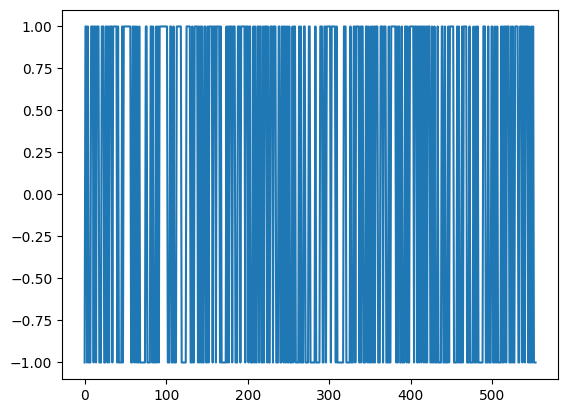

In [29]:
pd.Series([g.G.nodes[node]['direction'] for node in [*g.G.nodes]]).plot()

In [73]:
g.last_node

['__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'clear',
 'copy',
 'fromkeys',
 'get',
 'items',
 'keys',
 'pop',
 'popitem',
 'setdefault',
 'update',
 'values']

In [30]:
reversed([*g.G.nodes])

In [31]:
df_levels = []
for node in g.G.nodes:
    df_levels.append(g.G.nodes[node])
    
df_levels = pd.DataFrame(df_levels)

In [32]:
df_levels['inc'] = (df_levels['level'] > df_levels['level'].shift(1)).map(lambda x: 1 if x else -1)

In [35]:
df_levels['state'] = df_levels['inc'].cumsum()

<Axes: >

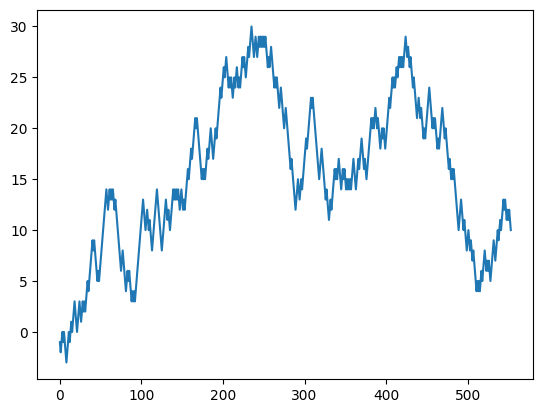

In [36]:
df_levels['state'].plot()

In [70]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = 'browser'

In [37]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True)

fig.add_trace(go.Scatter(x=df_levels.index, y=df_levels['state']), row=1, col=1)
fig.add_trace(go.Scatter(x=df_levels.index, y=df_levels['volume']), row=2, col=1)
pio.show(fig)

NameError: name 'make_subplots' is not defined

In [38]:
df_levels

,level,volume,direction,inc,state
0,33.5,404,-1,-1,-1
1,32.7,202,1,-1,-2
2,33.1,55,1,1,-1
3,33.4,143,-1,1,0
4,33.0,115,1,-1,-1
...,...,...,...,...,...
549,41.4,140,-1,1,12
550,40.8,290,1,-1,11
551,41.3,187,-1,1,12
552,40.8,51,-1,-1,11
